# ResNet-18 on CIFAR-10 实现实验

**实验目标**：
1.  从零开始实现ResNet-18网络架构，深刻理解残差连接（Residual Connection）的原理与作用。
2.  掌握使用PyTorch加载CIFAR-10数据集并进行标准数据增强的流程。
3.  构建完整的模型训练、验证和测试Pipeline。
4.  观察模型训练过程，分析损失和准确率曲线，学会初步的模型诊断。
5.  （可选）尝试调参，力争使模型在测试集上的准确率达到90%以上。

**环境确认**：
- 框架：PyTorch
- 硬件：CUDA (GPU)
- 关键库：`torch`, `torchvision`, `matplotlib`, `numpy`

## 理论核心：残差块（Residual Block / BasicBlock）

在开始编码前，请在脑海中或纸上明确两种基本残差块的结构：

1.  **身份快捷连接（Identity Shortcut）**
    - **适用情况**：当输入和输出特征图的维度（通道数、高、宽）完全相同时。
    - **结构**：
        `输入x -> 卷积层1 -> BN -> ReLU -> 卷积层2 -> BN -> 与输入x相加 -> ReLU -> 输出`
    - **计算**： `输出 = F(x) + x`

2.  **投影快捷连接（Projection Shortcut）**
    - **适用情况**：当需要下采样（高宽减半）或增加通道数时（例如每个Stage的第一个Block）。
    - **结构**：
        `主路径：输入x -> 卷积层1（stride=2）-> BN -> ReLU -> 卷积层2 -> BN`
        `快捷路径：输入x -> 1x1卷积（stride=2, 调整通道数）-> BN`
        `主路径输出 + 快捷路径输出 -> ReLU -> 输出`
    - **计算**： `输出 = F(x) + W_s * x` (其中 `W_s` 是1x1卷积和BN操作)

**思考**：为什么残差学习能有效解决深度网络的退化问题？

## 步骤一：数据准备与预处理

在本单元中，你需要完成以下操作：

1.  **导入必要库** (`torch`, `torchvision`, `matplotlib.pyplot`, `numpy`)。
2.  **定义数据转换（Transforms）**：
    - **训练集转换**：应包含：
        - `RandomCrop(32, padding=4)`
        - `RandomHorizontalFlip()`
        - `ToTensor()`
        - `Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])` (使用ImageNet的通用值，或计算CIFAR-10的自身均值标准差)
    - **测试集转换**：应包含：
        - `ToTensor()`
        - `Normalize()` (使用与训练集相同的均值和标准差)
3.  **下载/加载数据集**：
    - 使用`torchvision.datasets.CIFAR10`加载训练集和测试集，并应用上面定义好的转换。
4.  **创建数据加载器（DataLoader）**：
    - 设置`batch_size`（例如：128或256）。
    - 训练集DataLoader的`shuffle`参数应设为`True`，测试集设为`False`。
5.  **(可选) 可视化一些训练样本**：从DataLoader中取一个batch的数据，用`matplotlib`显示出来，检查数据增强后的效果和标签是否正确。

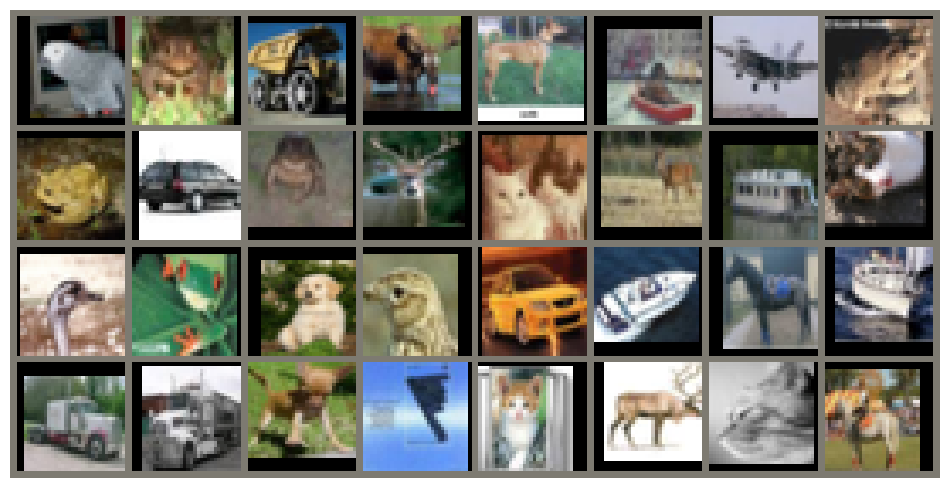

Device: cuda


In [2]:
# 在此Cell中完成数据准备的代码
# 1. 导入库
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
# 2. 定义Transforms
# ... your code here ...


transform_train = transforms.Compose(
    [transforms.RandomHorizontalFlip(p = 0.5),
     transforms.RandomCrop(32,padding=4),
     transforms.ToTensor(),
   transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])
     ])

transform_test = transforms.Compose([
    transforms.ToTensor,
       transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])
])

# 3. 加载数据集
# ... your code here ...

trainset = torchvision.datasets.CIFAR10(root = './data',
                                        train=True,
                                        download=True,
                                        transform=transform_train)
testset = torchvision.datasets.CIFAR10(root = './data',
                                       train=False,
                                       download=True,
                                       transform=transform_test)

# 4. 创建DataLoader
# ... your code here ...

batch_size = 128
trainloader = torch.utils.data.DataLoader(
  trainset,batch_size=batch_size,shuffle=True,num_workers=4,
  pin_memory=True)

testloader = torch.utils.data.DataLoader(
  testset,batch_size=batch_size,shuffle=True,num_workers=4,
  pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# 5. (可选) 可视化样本
# ... your code here ...

dataiter = iter(trainloader)
images,labes = next(dataiter)

def imshow(img):
    """
    将一个PyTorch Tensor图像显示出来。
    
    参数:
        img: 一个PyTorch Tensor，形状为 (C, H, W)
    """
    # 1. 反归一化 (Un-normalize)
    # 这是我们之前归一化操作的逆过程
    mean = torch.tensor([0.4914, 0.4822, 0.4465])
    std = torch.tensor([0.2023, 0.1994, 0.2010])
    img = img * std[:, None, None] + mean[:, None, None] # 广播机制，为mean/std添加H和W维度
    
    # 2. 将Tensor从GPU移回CPU（如果它在GPU上的话）
    img = img.cpu()
    
    # 3. 转换Tensor的格式： (C, H, W) -> (H, W, C)
    img = img.permute(1, 2, 0)
    
    # 4. 将图像数据裁剪回[0, 1]范围，防止反归一化后出现超出范围的值
    img = np.clip(img, 0, 1)
    
    # 5. 显示图像
    plt.imshow(img)
    plt.axis('off') # 关闭坐标轴
    
# 从批次中选择最多32张图像来显示
images_to_show = images[:32] # 选择前32张图片

# 创建图像网格
grid = torchvision.utils.make_grid(images_to_show, nrow=8, padding=2) 
# nrow: 每行显示的图像数量
# padding: 图像之间的像素间隔

# 显示网格
plt.figure(figsize=(12, 12)) # 设置整个画布的大小
imshow(grid) # 使用我们上面定义的imshow函数
plt.show()
# 检查CUDA是否可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

## 步骤二：实现残差块 (BasicBlock)

在本单元中，你需要编写`BasicBlock`类，它是构建ResNet-18的基石。

**你的任务**：
- 继承自`nn.Module`。
- 在`__init__`函数中定义网络层。根据传入的参数（如`in_planes`, `planes`, `stride`）判断是否需要使用投影快捷连接。
- 在`forward`函数中实现前向传播逻辑，明确地将主路径的输出和快捷路径的输出相加。

**提示**：
- 卷积层后通常接Batch Normalization（BN）层。
- 注意ReLU激活函数的位置：第一个ReLU在第一个卷积+BN之后，第二个ReLU在**残差相加之后**。
- 如果步长`stride != 1` 或者输入输出通道数不匹配，则必须使用1x1卷积（接BN）的投影快捷连接。

In [ ]:
class BasicBlock(nn.Module) :
    def __init__(self, in_channels,out_channels,kernel_size,stride,padding,downsample):
        super(BasicBlock,self).__init__()
        self.conv1 = nn.Conv2d(in_channels,out_channels,kernel_size,stride,padding,bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels,out_channels,kernel_size,1,padding,bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
    
    def forward(self,x) :
        identity = x
        out = self.bn1(self.conv1(x))
        out = self.relu(out)
        out = self.bn2(self.conv2(out))
        
        if self.downsample is not None:
            identity += self.downsample(x)
        
        out += identity
        out = self.relu(out)
        
        return out

## 步骤三：构建完整的ResNet-18网络

在本单元中，你需要编写`ResNet`类，并使用`BasicBlock`来搭建完整的网络。

**你的任务**：
1.  **`__init__`函数**：
    - 定义初始卷积层：`conv1`（建议：3x3卷积，stride=1, padding=1，输出64通道）。**注意**：这与原论文不同，是为了适应CIFAR-10的32x32小尺寸。
    - 定义BN层：`bn1`。
    - 定义四个主要阶段（`layer1`, `layer2`, `layer3`, `layer4`），每个阶段由多个`BasicBlock`组成。参考架构：
        - `layer1`: 2个Block, 64通道，stride=1
        - `layer2`: 2个Block, 128通道，**第一个Block的stride=2**
        - `layer3`: 2个Block, 256通道，**第一个Block的stride=2**
        - `layer4`: 2个Block, 512通道，**第一个Block的stride=2**
    - 定义全局平均池化层（`nn.AdaptiveAvgPool2d(1)`）。
    - 定义全连接层（`linear`），输出为10类。
2.  **`forward`函数**：按顺序组织各层的前向传播。
    - `x = self.conv1(x) -> self.bn1(x) -> F.relu(x)`
    - `x = self.layer1(x) -> self.layer2(x) -> self.layer3(x) -> self.layer4(x)`
    - `x = self.avgpool(x) -> torch.flatten(x, 1) -> self.linear(x)`

``` plantuml
@startuml
skinparam classAttributeIconSize 0

class ResNet {
  - conv1: Conv2d
  - bn1: BatchNorm2d
  - relu: ReLU
  - maxpool: MaxPool2d
  - layer1: Sequential
  - layer2: Sequential
  - layer3: Sequential
  - layer4: Sequential
  - avgpool: AdaptiveAvgPool2d
  - fc: Linear
  --
  - _make_layer(block, out_channels, blocks, stride): Sequential
  --
  + forward(x): Tensor
}

class BasicBlock {
  - conv1: Conv2d
  - bn1: BatchNorm2d
  - relu: ReLU
  - conv2: Conv2d
  - bn2: BatchNorm2d
  - downsample: Sequential?
  --
  + forward(x): Tensor
}

ResNet "1" *-- "many" BasicBlock : 通过 _make_layer 组合

@enduml
```

In [ ]:
class ResNet(nn.Module):
    def __init__(self):
        super(ResNet,self).__init__()
        self.conv1 = nn.Conv2d(3,64,3,1,1,bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3,stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(64)
        
        
        
    # def _make_layer(block,n_channels,out_channels,kernel_size,stride,padding,downsample):

## 步骤四：模型验证与参数量统计

**在开始训练前，务必进行此步骤！**

1.  **实例化模型**：创建一個ResNet-18的实例。
2.  **将模型移动到GPU**：使用`.to(device)`将模型参数转移到GPU上。
3.  **模型验证（前向传播测试）**：
    - 创建一个随机的模拟输入张量（`torch.randn`），shape为 `(2, 3, 32, 32)`。同样将其移动到GPU。
    - 将输入传递给模型。
    - **检查输出张量的shape是否为`(2, 10)`**。如果不是，说明网络架构存在错误，需要回溯调试。
4.  **计算参数量**：
    - 使用`sum(p.numel() for p in model.parameters())`计算模型总参数量。
    - 验证参数量是否在**1100万**左右。显著的偏差可能意味着层定义有误。

## 步骤五：定义训练组件

在本单元中，你需要配置训练模型所需的所有工具。

1.  **定义损失函数（Criterion）**：
    - `nn.CrossEntropyLoss()`
2.  **定义优化器（Optimizer）**：
    - 使用随机梯度下降（SGD）：`optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)`
    - **注意**：初始学习率`lr`是接下来需要调整的最重要超参数之一。
3.  **定义学习率调度器（Scheduler）**：
    - 使用`MultiStepLR`：在指定的epoch降低学习率。
    - 例如：`scheduler = MultiStepLR(optimizer, milestones=[100, 150], gamma=0.1)` 表示在第100和150个epoch时，将学习率乘以0.1。

## 步骤六：编写训练与验证循环

这是实验最核心的循环部分。

1.  **初始化记录列表**：用于记录每个epoch的训练损失/准确率，测试损失/准确率。
2.  **循环多个Epoch**。
3.  **训练阶段 (一个Epoch内)**：
    - 将模型设置为训练模式：`model.train()`
    - 遍历训练集DataLoader。
    - 对每个batch：将数据移至GPU -> 清零梯度 -> 前向传播 -> 计算损失 -> 反向传播 -> 优化器更新。
    - 计算并记录这个epoch的平均训练损失和准确率。
4.  **验证/测试阶段 (一个Epoch后)**：
    - 将模型设置为评估模式：`model.eval()`
    - 使用`torch.no_grad()`上下文管理器，禁止梯度计算。
    - 遍历测试集DataLoader，计算损失和准确率。
    - 记录这个epoch的平均测试损失和准确率。
5.  **更新学习率**：调用`scheduler.step()`。
6.  **打印日志**：每训练一个epoch，都打印出当前的epoch数、训练损失/准确率、测试损失/准确率。

## 步骤七：可视化训练过程并分析结果

训练完成后，在本单元进行可视化分析。

1.  **绘制损失曲线**：将训练损失和测试损失绘制在同一张图上。
2.  **绘制准确率曲线**：将训练准确率和测试准确率绘制在同一张图上。
3.  **分析曲线**：
    - **正常情况**：两条损失曲线都下降并最终趋于平稳，两条准确率曲线都上升并最终趋于平稳。测试准确率应最终稳定在一个值附近。
    - **过拟合**：训练准确率持续显著高于测试准确率，且测试准确率很早就停止增长甚至开始下降。
    - **欠拟合**：训练和测试准确率都很低，且曲线很早就变得平缓。
    - **不收敛**：损失值不下降或变成NaN。

**记录你的最终测试准确率**：__________________

## 步骤八：保存模型与下一步挑战

**保存模型**：
- 使用`torch.save(model.state_dict(), 'resnet18_cifar10.pth')`保存训练好的模型权重。

**进阶挑战（选择完成）**：
- **超参数调优**：调整初始学习率、批大小、权重衰减等，尝试突破95%的测试准确率。
- **尝试预激活结构**：实现ResNet V2的“BN-ReLU-Conv”预激活块，比较训练效果。
- **可视化**：使用`torchcam`或自己实现Grad-CAM，可视化模型在测试图像上的关注点。
- **学习率热身（Warmup）**：在训练最初的一些epoch采用较低的学习率，然后逐渐增加到初始值，观察是否对训练稳定性有帮助。

**实验总结与反思**：
请在此记录本次实验的心得、遇到的问题和解决方案。